# **1.Importación y configuración de recursos**

In [1]:
#Verificamos que estemos usando la versión de python instalada en nuestro cluster mediante conda
import sys
print(sys.executable)

/home/estudiante/miniconda3/bin/python3


In [2]:
#Importación de todas las bibliotecas necesarias para procesamiento, gráficas y otros recursos
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# Bibliotecas especializadas
from pylab import *

In [3]:
import os

# Ajuste de las variables de entorno
os.environ["PYSPARK_PYTHON"] = "/home/estudiante/miniconda3/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/home/estudiante/miniconda3/bin/python3"

print("Usando Python en:", os.environ["PYSPARK_PYTHON"])

Usando Python en: /home/estudiante/miniconda3/bin/python3


In [4]:
# Bibliotecas de Contexto PySpark, MLlib y contexto para levantar la sesión de PYSPARK

#Búsqueda de inicialización para pyspark
import findspark
findspark.init()

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession, SQLContext

from pyspark.sql.types import *
import pyspark.sql.functions as F # Acceso a todas las funciones

from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator

In [5]:
#Se crea una sesión para hacer el contexto de procesamiento desde mi Cuota de cluster HPC (No tenemos acceso a todos los cores, son compartidos)
from pyspark import SparkConf
##Se levanta la configuración de mi Cuota
configura = SparkConf().set("spark.scheduler.mode", "FAIR")

configura.setAppName("Preguntas_Clave_Proyecto")

sparkSPG = SparkSession.builder.config(conf=configura).getOrCreate()
SQLContext(sparkContext = sparkSPG.sparkContext, sparkSession = sparkSPG)

contextoSparkSPG = sparkSPG.sparkContext.getOrCreate()

print("Sesión cluster Preguntas Clave")

sparkSPG

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/14 11:24:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/14 11:24:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/14 11:24:36 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Sesión cluster Preguntas Clave


## **Lectura de archivos Parquet**

In [6]:
df_Arrestos = sparkSPG.read.parquet("/almacen/proyecto/parquet/df_Arrestos.parquet")
df_Arrestos.show(5)

+----------+-----------+----------+----------+-----------+---------------+---------+--------+--------------+----------+----------+------------------+------------------+--------------------+-----------+
|ARREST_KEY|ARREST_DATE|  LAW_CODE|LAW_CAT_CD|ARREST_BORO|ARREST_PRECINCT|AGE_GROUP|PERP_SEX|     PERP_RACE|X_COORD_CD|Y_COORD_CD|          Latitude|         Longitude|             Lon_Lat|AgeCategory|
+----------+-----------+----------+----------+-----------+---------------+---------+--------+--------------+----------+----------+------------------+------------------+--------------------+-----------+
| 183457321| 06/04/2018|PL 1200600|         F|          2|             83|    45-64|       1|         BLACK|   1007128|    193705| 40.69833089400004|-73.91749507299994|POINT (-73.917495...|          4|
| 183451014| 06/04/2018|PL 1552500|         M|          3|             14|    25-44|       1|         BLACK|    987220|    212676| 40.75043076800005|-73.98928217599996|POINT (-73.989282...|   

In [7]:
df_Escuelas = sparkSPG.read.parquet("/almacen/proyecto/parquet/df_crimenesEscuela.parquet")
df_Escuelas.show(5)

+-------+-------+-----+--------+------+-----+------------+----------+-------------+-----------+----------+
|Borough|Major N|Oth N|NoCrim N|Prop N|Vio N|AvgOfMajor N|AvgOfOth N|AvgOfNoCrim N|AvgOfProp N|AvgOfVio N|
+-------+-------+-----+--------+------+-----+------------+----------+-------------+-----------+----------+
|      3|      0|    0|       3|     0|    0|        0.25|      0.88|         1.69|       0.57|      0.45|
|      2|      1|    1|       0|     2|    0|        0.38|      1.52|         3.88|       0.83|      0.91|
|      3|      1|   11|       8|     6|    4|        0.25|      1.03|         2.22|       0.55|      0.58|
|      3|      1|    4|       1|     1|    3|        0.25|      0.88|         1.69|       0.57|      0.45|
|      2|      0|    2|       3|     2|    0|        0.25|      1.03|         2.22|       0.55|      0.58|
+-------+-------+-----+--------+------+-----+------------+----------+-------------+-----------+----------+
only showing top 5 rows



In [8]:
df_Pobreza = sparkSPG.read.parquet("/almacen/proyecto/parquet/df_Pobreza.parquet")
df_Pobreza.show(5)

+----+--------+----+----------+---+----+----+---+---------+---+---+----+---+----------+---+-----------+---+-------------+---------------+-------------+---------------+---------------+------------+---------+-------------+-----------------+
|AGEP|AgeCateg|Boro|EducAttain|SCH|SCHG|SCHL|CIT|Ethnicity|SEX|ENG|LANX|MSP|FamType_PU| NP|EST_Housing|TEN|EST_IncomeTax|EST_PovGapIndex|NYCgov_Income|PreTaxIncome_PU|NYCgov_Pov_Stat|Off_Pov_Stat| RNTP_adj|EST_Nutrition|AgeCategoryArrest|
+----+--------+----+----------+---+----+----+---+---------+---+---+----+---+----------+---+-----------+---+-------------+---------------+-------------+---------------+---------------+------------+---------+-------------+-----------------+
|  49|       2|   2|         1|  1|   0|  14|  4|        4|  2|  3|   1|  4|         4|  2|  3438.6116|  3|   -5837.0474|     0.04411475|    23427.465|      19248.844|              1|           2|719.29889|        803.5|                4|
|  16|       1|   2|         1|  2|  12|  13

25/11/14 11:24:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


## **Respuesta a las preguntas clave planteadas**

Pregunta 1: ¿Como se comparan los niveles de arrestos entre distintos distritos de New York en relacion a la cantidad de crimenes escolares reportados de cada uno?

In [9]:
from pyspark.sql.functions import col, sum as _sum, when

# Mapeo opcional de códigos a nombres
mapping = (when(col("ARREST_BORO") == "1", "Manhattan")
           .when(col("ARREST_BORO") == "2", "Bronx")
           .when(col("ARREST_BORO") == "3", "Brooklyn")
           .when(col("ARREST_BORO") == "4", "Queens")
           .when(col("ARREST_BORO") == "5", "Staten Island"))

df_Arrestos2 = df_Arrestos.withColumn("BoroughName", mapping)

arrestos_por_barrio = (
    df_Arrestos2.groupBy("ARREST_BORO", "BoroughName")
    .count()
    .withColumnRenamed("count", "ArrestosTotales")
)


In [10]:
from pyspark.sql.functions import col

df_Escuelas2 = df_Escuelas.withColumn(
    "TotalCrimenesEscolares",
    col("Major N") + col("Oth N") + col("NoCrim N") + col("Prop N") + col("Vio N")
)

crimenes_por_barrio = (
    df_Escuelas2.groupBy("Borough")
    .agg(_sum("TotalCrimenesEscolares").alias("CrimenesEscolaresTotales"))
)

In [11]:
comparacion = arrestos_por_barrio.join(
    crimenes_por_barrio,
    arrestos_por_barrio.ARREST_BORO == crimenes_por_barrio.Borough,
    "inner"
).select(
    "BoroughName",
    "ArrestosTotales",
    "CrimenesEscolaresTotales"
)

comparacion.show()


+-------------+---------------+------------------------+
|  BoroughName|ArrestosTotales|CrimenesEscolaresTotales|
+-------------+---------------+------------------------+
|    Manhattan|          55446|                  2713.0|
|     Brooklyn|          62582|                  1814.0|
|Staten Island|          10424|                   541.0|
|       Queens|          49916|                  1526.0|
|        Bronx|          68405|                  2851.0|
+-------------+---------------+------------------------+



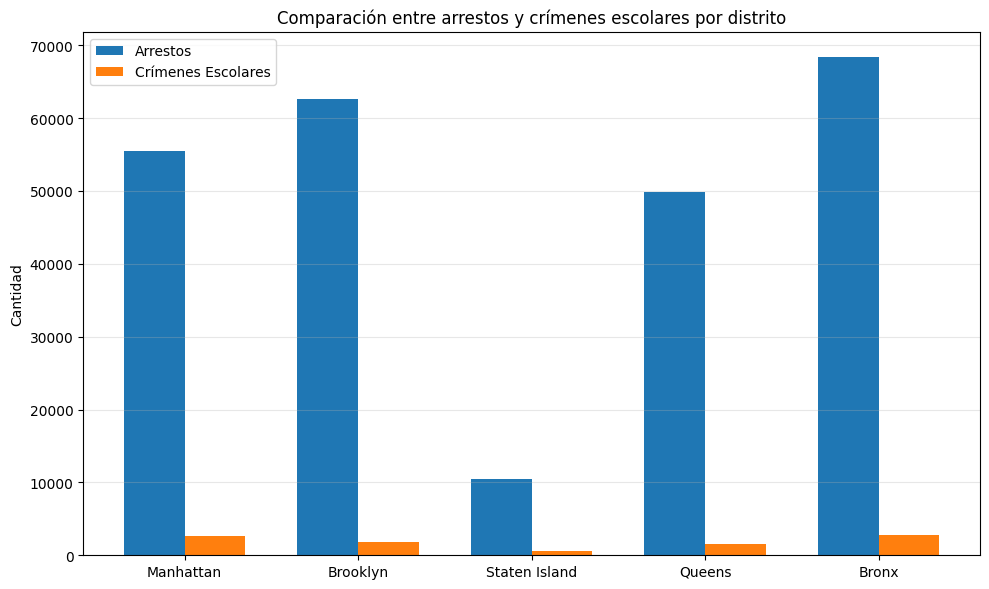

In [12]:
pdf = comparacion.toPandas()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

x = np.arange(len(pdf))
ancho = 0.35

plt.bar(x - ancho/2, pdf["ArrestosTotales"], width=ancho, label="Arrestos")
plt.bar(x + ancho/2, pdf["CrimenesEscolaresTotales"], width=ancho, label="Crímenes Escolares")

plt.xticks(x, pdf["BoroughName"])
plt.ylabel("Cantidad")
plt.title("Comparación entre arrestos y crímenes escolares por distrito")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



Pregunta 2: ¿Que relacíon existe entre las causas de arresto y las condiciones de pobreza de las personas involucradas en cada distrito?

In [13]:
from pyspark.sql.functions import when, col, count, avg

# ---- 1. Clasificación general por categorías ----
df_Arrestos = df_Arrestos.withColumn(
    "CategoriaDelito",
    when(col("LAW_CODE").startswith("PL 120"), "Agresiones")
    .when(col("LAW_CODE").startswith("PL 155"), "Robos/Hurtos")
    .when(col("LAW_CODE").startswith("PL 140"), "Robos/Hurtos")
    .when(col("LAW_CODE").startswith("PL 160"), "Robos/Hurtos")
    .when(col("LAW_CODE").startswith("PL 220"), "Drogas")
    .when(col("LAW_CODE").startswith("PL 221"), "Drogas")
    .when(col("LAW_CODE").startswith("PL 265"), "Armas")
    .when(col("LAW_CODE").startswith("PL 165"), "Tránsito")
    .when(col("LAW_CODE").startswith("PL 215"), "Desobediencia / Citaciones")
    .when(col("LAW_CODE").startswith("VTL"), "Tránsito")
    .otherwise("Otros")
)

# ---- 2. Agregación por barrio y LAW_CODE ----
arrestos_por_ley = (
    df_Arrestos
    .groupBy("ARREST_BORO", "LAW_CODE")
    .agg(count("*").alias("NumArrestos"))
)

# ---- 3. Agregación por categoría general ----
delitos_por_categoria = (
    df_Arrestos
    .groupBy("ARREST_BORO", "CategoriaDelito")
    .agg(count("*").alias("NumArrestos"))
)

# ---- 4. Dataset de pobreza promedio por distrito ----
pobreza_boro = df_Pobreza.groupBy("Boro").agg(
    avg("EST_PovGapIndex").alias("PobrezaPromedio")
)

# ---- 5. Join con pobreza: versión por LAW_CODE ----
arrestos_pobreza_ley = (
    arrestos_por_ley
    .join(pobreza_boro, arrestos_por_ley.ARREST_BORO == pobreza_boro.Boro)
    .select("ARREST_BORO", "LAW_CODE", "NumArrestos", "PobrezaPromedio")
)

# ---- 6. Join con pobreza: versión por categoría ----
arrestos_pobreza_categoria = (
    delitos_por_categoria
    .join(pobreza_boro, delitos_por_categoria.ARREST_BORO == pobreza_boro.Boro)
    .select("ARREST_BORO", "CategoriaDelito", "NumArrestos", "PobrezaPromedio")
)

# Convertimos ambos a pandas
pdf_ley = arrestos_pobreza_ley.toPandas()
pdf_cat = arrestos_pobreza_categoria.toPandas()


In [14]:
from pyspark.sql.functions import count, avg

# --- 1. Arrestos por causa (categoría) y distrito ---
tabla_simplificada = (
    df_Arrestos
    .groupBy("ARREST_BORO", "CategoriaDelito")
    .agg(count("*").alias("NumArrestos"))
)

# --- 2. Promedio de pobreza por distrito ---
pobreza_boro = (
    df_Pobreza
    .groupBy("Boro")
    .agg(avg("EST_PovGapIndex").alias("PobrezaPromedio"))
)

# --- 3. Unión final ---
tabla_final = (
    tabla_simplificada
    .join(pobreza_boro, tabla_simplificada.ARREST_BORO == pobreza_boro.Boro)
    .select(
        "ARREST_BORO",
        "CategoriaDelito",
        "NumArrestos",
        "PobrezaPromedio"
    )
)

pdf_final = tabla_final.toPandas()
pdf_final


,ARREST_BORO,CategoriaDelito,NumArrestos,PobrezaPromedio
0,1,Drogas,8812,0.085353
1,1,Desobediencia / Citaciones,2474,0.085353
2,1,Armas,2410,0.085353
3,1,Agresiones,12803,0.085353
4,1,Otros,11131,0.085353
5,1,Tránsito,8518,0.085353
6,1,Robos/Hurtos,9298,0.085353
7,3,Drogas,7541,0.057645
8,3,Agresiones,9085,0.057645
9,3,Desobediencia / Citaciones,2006,0.057645


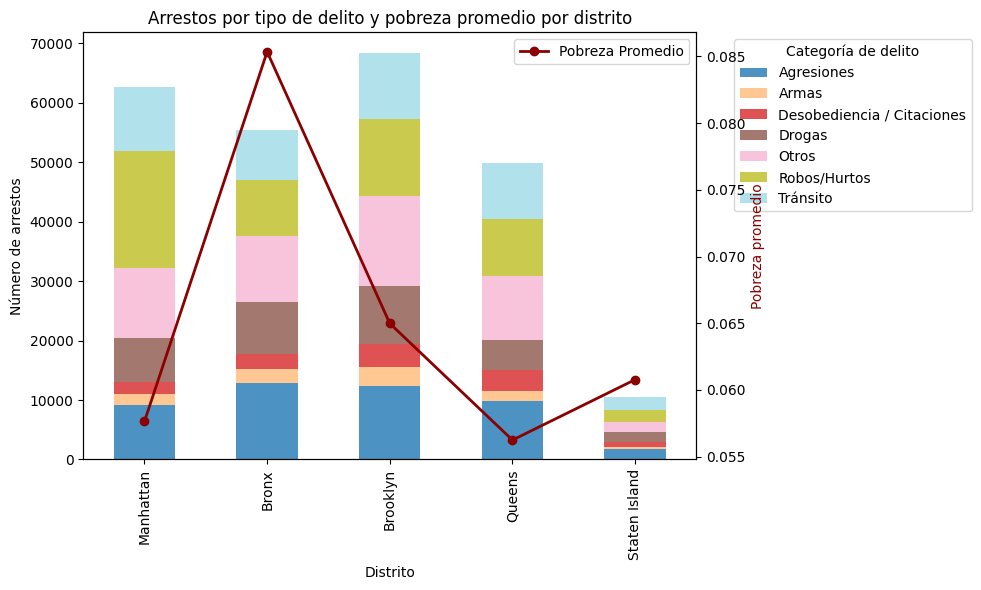

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Mapear códigos de distrito a nombres ---
from pyspark.sql.functions import when, col

tabla_final_map = tabla_final.withColumn(
    "Distrito",
    when(col("ARREST_BORO") == "1", "Bronx")
    .when(col("ARREST_BORO") == "2", "Brooklyn")
    .when(col("ARREST_BORO") == "3", "Manhattan")
    .when(col("ARREST_BORO") == "4", "Queens")
    .when(col("ARREST_BORO") == "5", "Staten Island")
)

# --- 2. Convertir a pandas ---
pdf_final_map = tabla_final_map.select(
    "Distrito", "CategoriaDelito", "NumArrestos", "PobrezaPromedio"
).toPandas()

# --- 3. Preparar datos para barras apiladas ---
barras = pdf_final_map.pivot_table(
    index='Distrito',
    columns='CategoriaDelito',
    values='NumArrestos',
    fill_value=0
)

# Ordenar los distritos para que aparezcan en orden geográfico típico
orden_distritos = ["Manhattan", "Bronx", "Brooklyn", "Queens", "Staten Island"]
barras = barras.reindex(orden_distritos)

# --- 4. Preparar línea de pobreza ---
# Como la pobreza es igual por distrito, podemos tomar la primera fila de cada distrito
pobreza = pdf_final_map.groupby("Distrito")["PobrezaPromedio"].first().reindex(orden_distritos)

# --- 5. Graficar ---
fig, ax1 = plt.subplots(figsize=(10,6))

# Barras apiladas
barras.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20', alpha=0.8)

ax1.set_xlabel("Distrito")
ax1.set_ylabel("Número de arrestos")
ax1.set_title("Arrestos por tipo de delito y pobreza promedio por distrito")

# Segundo eje = pobreza promedio
ax2 = ax1.twinx()
ax2.plot(pobreza.index, pobreza.values, color='darkred', marker='o', linewidth=2, label='Pobreza Promedio')
ax2.set_ylabel("Pobreza promedio", color='darkred')

# Leyenda combinada
ax1.legend(title="Categoría de delito", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()



Pregunta 3: ¿Cuál es la correlación entre el nivel educativo promedio de la población y la cantidad de arrestos registrados en los distritos con mayores índices de pobreza?

In [16]:
df_edu_nvl = (
    df_Pobreza.groupBy("Boro")
    .agg(F.avg("EducAttain").alias("Promedio_Educativo"))
)

In [17]:
df_arrestos_totales = (
    df_Arrestos.groupBy("ARREST_BORO")
    .agg(F.countDistinct("ARREST_KEY").alias("Total_Arrestos"))
)

In [18]:
df_join03 = df_arrestos_totales.join(
    df_edu_nvl,
    df_arrestos_totales.ARREST_BORO == df_edu_nvl.Boro,
    "inner"
).select(
    F.col("Boro"),
    F.col("Total_Arrestos"),
    F.col("Promedio_Educativo")
)

In [19]:
# Filtrar solo los distritos Bronx (1), Brooklyn (2) y Manhattan (3)
df_filtro03 = df_join03.filter(F.col("Boro").isin([1, 2, 3]))

In [20]:
df_filtro03 = df_filtro03.withColumn(
    "Distrito",
    F.when(F.col("Boro") == 1, "Bronx")
     .when(F.col("Boro") == 2, "Brooklyn")
     .when(F.col("Boro") == 3, "Manhattan")
     .otherwise("Otro")
)

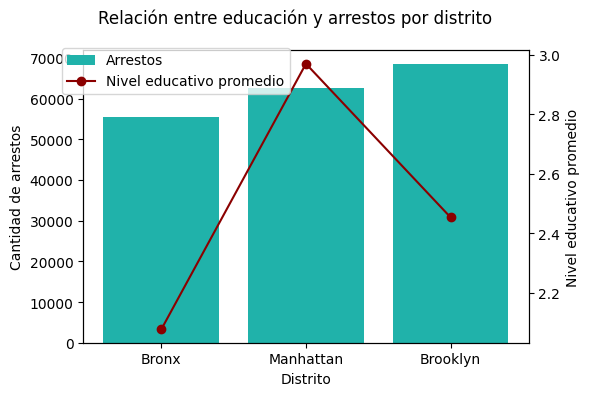

In [21]:
df_plot = df_filtro03.toPandas()

fig, ax1 = plt.subplots(figsize=(6,4))

# Barras: cantidad de arrestos
ax1.bar(df_plot["Distrito"], df_plot["Total_Arrestos"], color="lightseagreen", label="Arrestos")
ax1.set_xlabel("Distrito")
ax1.set_ylabel("Cantidad de arrestos")

# Segundo eje: nivel educativo promedio
ax2 = ax1.twinx()
ax2.plot(df_plot["Distrito"], df_plot["Promedio_Educativo"], color="darkred", marker="o", label="Nivel educativo promedio")
ax2.set_ylabel("Nivel educativo promedio")

# Título y leyenda combinada
fig.suptitle("Relación entre educación y arrestos por distrito", fontsize=12)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.tight_layout()
plt.show()




Pregunta 4: ¿En qué distritos se concentran los niveles más altos de criminalidad escolar y cómo se relacionan con el contexto socioeconómico de esas zonas?

In [22]:
# === 1. Calcular crímenes escolares totales por distrito ===
df_crimen_escuelas = df_Escuelas.withColumn(
    "Total_Crimen",
    F.col("Major N") + F.col("Oth N") + F.col("NoCrim N") + F.col("Prop N") + F.col("Vio N")
)

df_crimen_boro = df_crimen_escuelas.groupBy("Borough").agg(F.sum("Total_Crimen").alias("Total_Crimenes_Escolares"))

# === 2. Calcular indicadores socioeconómicos promedio por distrito ===
df_socioeconomico = df_Pobreza.groupBy("Boro").agg(
    F.avg("NYCgov_Income").alias("Ingreso_Promedio"),
    F.avg("EST_PovGapIndex").alias("Brecha_Pobreza_Promedio")
)

# === 3. JOIN entre ambos ===
df_join04 = df_crimen_boro.join(df_socioeconomico, df_crimen_boro["Borough"] == df_socioeconomico["Boro"], how="inner")

# === 4. Filtrar distritos de interés (Bronx, Brooklyn, Manhattan) ===
df_join04 = df_join04.filter(F.col("Boro").isin([1, 2, 3]))

# === 5. Añadir nombre descriptivo ===
df_join04 = df_join04.withColumn(
    "Distrito",
    F.when(F.col("Boro") == 1, "Bronx")
     .when(F.col("Boro") == 2, "Brooklyn")
     .when(F.col("Boro") == 3, "Manhattan")
)


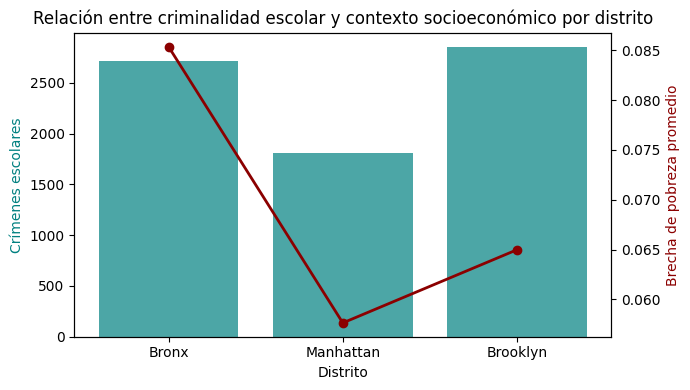

In [23]:
df_plot = df_join04.toPandas()

fig, ax1 = plt.subplots(figsize=(7,4))

# Barras = cantidad de crímenes escolares
ax1.bar(df_plot["Distrito"], df_plot["Total_Crimenes_Escolares"], color="teal", alpha=0.7)
ax1.set_xlabel("Distrito")
ax1.set_ylabel("Crímenes escolares", color="teal")

# Segundo eje = brecha de pobreza promedio
ax2 = ax1.twinx()
ax2.plot(df_plot["Distrito"], df_plot["Brecha_Pobreza_Promedio"], color="darkred", marker="o", linewidth=2)
ax2.set_ylabel("Brecha de pobreza promedio", color="darkred")

plt.title("Relación entre criminalidad escolar y contexto socioeconómico por distrito")
plt.tight_layout()
plt.show()


Pregunta 5: ¿En qué medida la pobreza de un distrito influye en la cantidad de arrestos registrados 
en esa zona? 

In [24]:
# Se realiza el Join de pobreza con el dataframe de arrestos
df_pobreza_prom = (
    df_Pobreza.groupBy("Boro")
    .agg(F.avg("EST_PovGapIndex").alias("Promedio_Brecha_Pobreza"))
)

df_join05 = df_arrestos_totales.join(
    df_pobreza_prom,
    df_pobreza_prom.Boro == df_arrestos_totales.ARREST_BORO,
    how="inner"
).select(
    F.col("Boro"),
    F.col("Promedio_Brecha_Pobreza"),
    F.col("Total_Arrestos")
)

df_join05.show(10)

+----+-----------------------+--------------+
|Boro|Promedio_Brecha_Pobreza|Total_Arrestos|
+----+-----------------------+--------------+
|   1|     0.0853525642820143|         55446|
|   3|   0.057645420057599504|         62582|
|   5|    0.06077619880470146|         10424|
|   4|   0.056246913082597466|         49916|
|   2|    0.06498814646897616|         68405|
+----+-----------------------+--------------+



/tmp/ipykernel_188302/1983030395.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


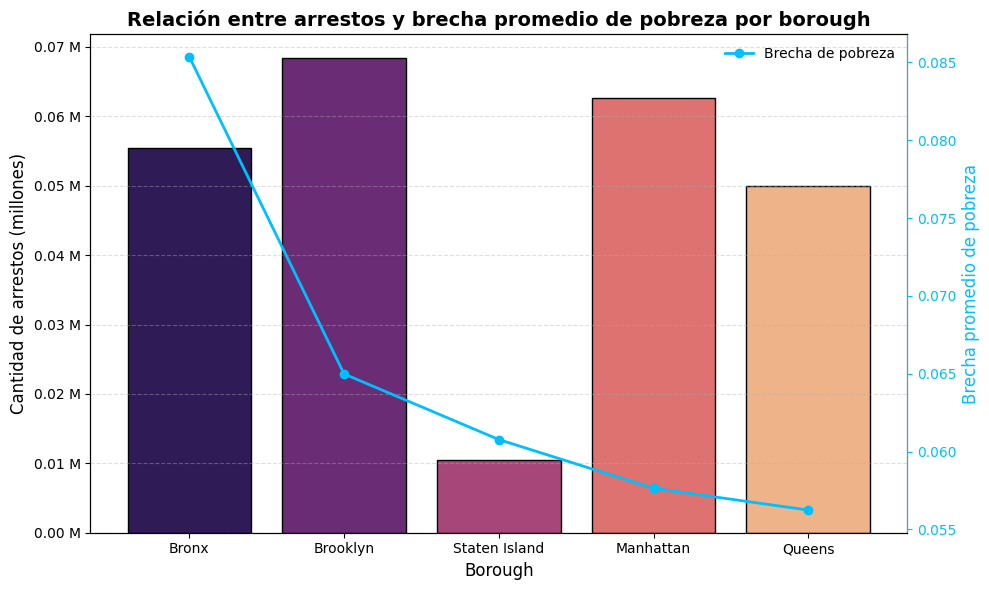

In [25]:
# Se realiza la gráfica comparando la proporción de pobreza con el total de arrestos

### Se modifica el Dataframe para que se vea bien la gráfica

pdf_join05 = df_join05.toPandas()

# Mapeo de nombres de borough
nombres_borough = {
    1: "Bronx",
    2: "Brooklyn",
    3: "Manhattan",
    4: "Queens",
    5: "Staten Island"
}
pdf_join05["Borough"] = pdf_join05["Boro"].map(nombres_borough)

# Escalar arrestos a millones
pdf_join05["Total_Arrestos_Millones"] = pdf_join05["Total_Arrestos"] / 1_000_000

# Ordenado por proporción de pobreza promedio
pdf_join05 = pdf_join05.sort_values("Promedio_Brecha_Pobreza", ascending=False)

### Construccion de la gráfica

fig, ax1 = plt.subplots(figsize=(10,6))

# --- Barras: Cantidad de arrestos ---
sns.barplot(
    data=pdf_join05,
    x="Borough",
    y="Total_Arrestos_Millones",
    palette="magma",
    edgecolor="black",
    ax=ax1
)

# --- Segundo eje: Brecha de pobreza promedio ---
ax2 = ax1.twinx()
ax2.plot(
    pdf_join05["Borough"],
    pdf_join05["Promedio_Brecha_Pobreza"],
    color="deepskyblue",
    marker="o",
    linewidth=2,
    label="Brecha de pobreza"
)

# Demás ajustes estéticos

ax1.set_title("Relación entre arrestos y brecha promedio de pobreza por borough", fontsize=14, weight="bold")
ax1.set_xlabel("Borough", fontsize=12)
ax1.set_ylabel("Cantidad de arrestos (millones)", fontsize=12, color="black")
ax2.set_ylabel("Brecha promedio de pobreza", fontsize=12, color="deepskyblue")

ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} M"))

ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines["right"].set_color("deepskyblue")
ax2.tick_params(axis="y", colors="deepskyblue")

ax2.legend(loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

Pregunta 6: ¿Hasta qué punto el nivel educativo promedio de la población reduce o aumenta los 
casos de criminalidad escolar?

In [26]:
# Agregaciones
# Nivel educativo promedio 
df_edu_prom = (
    df_Pobreza.groupBy("Boro")
    .agg(F.avg("EducAttain").alias("Promedio_Educativo"))
)

# Promedio de criminalidad escolar
df_crimen_prom = (
    df_Escuelas.groupBy("Borough")
    .agg(
        F.avg("Major N").alias("Promedio_MajorN"),
        F.avg("Vio N").alias("Promedio_Violencia"),
        F.avg("Prop N").alias("Promedio_Propiedad"),
        F.avg("NoCrim N").alias("Promedio_NoCrim")
    )
)

In [27]:
#Join
df_join_06 = df_edu_prom.join(
    df_crimen_prom,
    df_crimen_prom.Borough == df_edu_prom.Boro,
    how="inner"
).select(
    F.col("Boro"),
    F.col("Promedio_Educativo"),
    F.col("Promedio_MajorN").alias("Promedio_Criminalidad")
)

/tmp/ipykernel_188302/1593146279.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


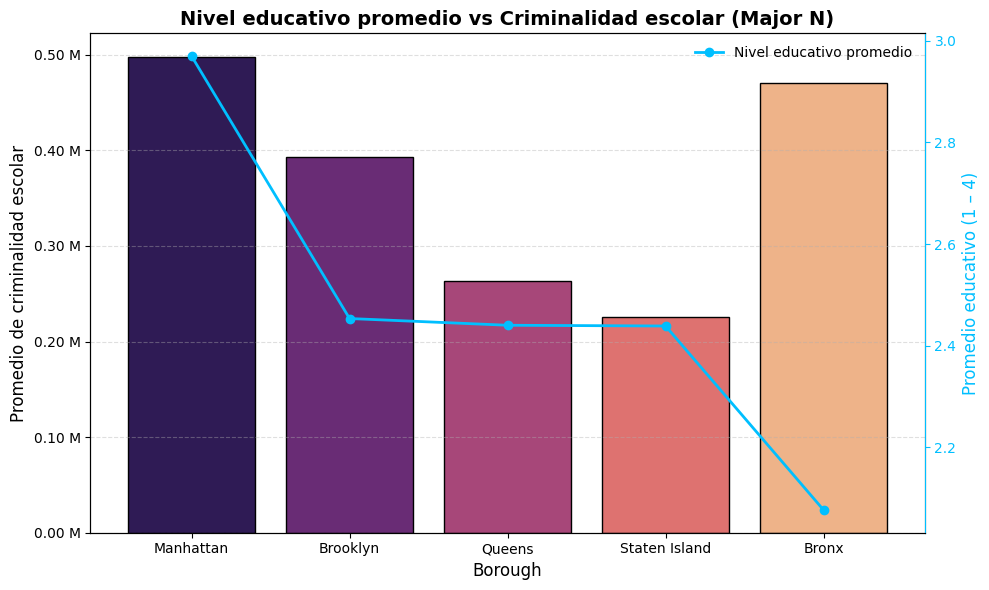

In [28]:
# Convertir a Pandas
pdf_join_06 = df_join_06.toPandas()

# Mapeo de nombres de borough
nombres_borough = {
    1: "Bronx",
    2: "Brooklyn",
    3: "Manhattan",
    4: "Queens",
    5: "Staten Island"
}
pdf_join_06["Borough"] = pdf_join_06["Boro"].map(nombres_borough)

# Ordenar por nivel educativo
pdf_join_06 = pdf_join_06.sort_values("Promedio_Educativo", ascending=False)

# Gráfico combinado (barras + línea)
fig, ax1 = plt.subplots(figsize=(10,6))

# --- Barras: criminalidad escolar promedio ---
sns.barplot(
    data=pdf_join_06,
    x="Borough",
    y="Promedio_Criminalidad",
    palette="magma",
    edgecolor="black",
    ax=ax1
)

# --- Línea: nivel educativo promedio ---
ax2 = ax1.twinx()
ax2.plot(
    pdf_join_06["Borough"],
    pdf_join_06["Promedio_Educativo"],
    color="deepskyblue",
    marker="o",
    linewidth=2,
    label="Nivel educativo promedio"
)

# Formato
ax1.set_title("Nivel educativo promedio vs Criminalidad escolar (Major N)", fontsize=14, weight="bold")
ax1.set_xlabel("Borough", fontsize=12)
ax1.set_ylabel("Promedio de criminalidad escolar", fontsize=12)
ax2.set_ylabel("Promedio educativo (1 – 4)", fontsize=12, color="deepskyblue")

ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines["right"].set_color("deepskyblue")
ax2.tick_params(axis="y", colors="deepskyblue")
ax2.legend(loc="upper right", frameon=False)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} M"))

plt.tight_layout()
plt.show()

Pregunta 7: ¿En qué medida los distritos con mayores tasas de pobreza presentan también más 
causas de arresto relacionadas con delitos menores Vs delitos mayores? 

In [29]:
# Agregaciones

# Filtrar solo los arrestos por delitos menores
df_misdemeanor = df_Arrestos.filter(F.col("LAW_CAT_CD") == "M")

# Contar cantidad de arrestos por borough
df_arrestos_menores = (
    df_misdemeanor.groupBy("ARREST_BORO")
    .agg(F.countDistinct("ARREST_KEY").alias("Total_Arrestos_Menores"))
)

# Delitos mayores
df_felony = df_Arrestos.filter(F.col("LAW_CAT_CD") == "F")

# Contar cantidad de arrestos por borough
df_arrestos_mayores = (
    df_felony.groupBy("ARREST_BORO")
    .agg(F.countDistinct("ARREST_KEY").alias("Total_Arrestos_Mayores"))
)

# Calcular el promedio del índice de pobreza por borough
df_pobreza_prom = (
    df_Pobreza.groupBy("Boro")
    .agg(F.avg("EST_PovGapIndex").alias("Promedio_Brecha_Pobreza"))
)

In [30]:
# Unir dataframes
df_comparacion = df_arrestos_menores.join(
    df_arrestos_mayores,
    on="ARREST_BORO",
    how="inner"
).join(
    df_pobreza_prom,
    df_pobreza_prom.Boro == df_arrestos_menores.ARREST_BORO,
    "inner"
).select(
    F.col("Boro"),
    F.col("Promedio_Brecha_Pobreza"),
    F.col("Total_Arrestos_Menores"),
    F.col("Total_Arrestos_Mayores")
)

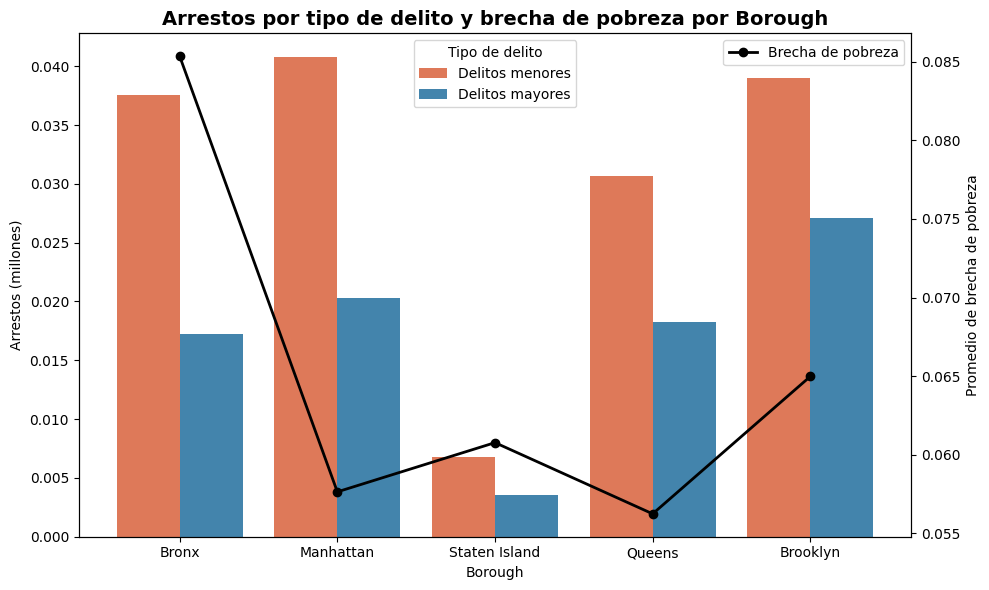

In [31]:
pdf_comp = df_comparacion.toPandas()

# Mapear nombres
nombres_borough = {
    1: "Bronx",
    2: "Brooklyn",
    3: "Manhattan",
    4: "Queens",
    5: "Staten Island"
}
pdf_comp["Borough"] = pdf_comp["Boro"].map(nombres_borough)

# Escalar a millones
pdf_comp["Arrestos_Menores_M"] = pdf_comp["Total_Arrestos_Menores"] / 1_000_000
pdf_comp["Arrestos_Mayores_M"] = pdf_comp["Total_Arrestos_Mayores"] / 1_000_000

# Reorganizar el DataFrame para graficar 
pdf_long = pdf_comp.melt(
    id_vars=["Borough", "Promedio_Brecha_Pobreza"],
    value_vars=["Arrestos_Menores_M", "Arrestos_Mayores_M"],
    var_name="Tipo_Delito",
    value_name="Arrestos_Millones"
)

# Renombrar etiquetas
pdf_long["Tipo_Delito"] = pdf_long["Tipo_Delito"].replace({
    "Arrestos_Menores_M": "Delitos menores",
    "Arrestos_Mayores_M": "Delitos mayores"
})

# Colores fijos por borough (opcional, para consistencia visual)
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(
    data=pdf_long,
    x="Borough",
    y="Arrestos_Millones",
    hue="Tipo_Delito",
    palette=["#F46D43", "#3288BD"],
    errorbar=None,
    ax=ax1
)

# Línea secundaria con pobreza
ax2 = ax1.twinx()
ax2.plot(
    pdf_comp["Borough"],
    pdf_comp["Promedio_Brecha_Pobreza"],
    color="black", marker="o", linewidth=2, label="Brecha de pobreza"
)

ax1.set_title("Arrestos por tipo de delito y brecha de pobreza por Borough", fontsize=14, weight="bold")
ax1.set_ylabel("Arrestos (millones)")
ax2.set_ylabel("Promedio de brecha de pobreza", color="black")
ax1.legend(title="Tipo de delito")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

Pregunta 8: ¿Como varia la relacion entre pobreza y criminalidad escolar, entre distritos como Bronx, Manhattan y Broklin?

In [32]:
from pyspark.sql.functions import avg, col

# 3.1 Promedio de crímenes escolares por distrito
crimenes_escolares = df_Escuelas.groupBy("Borough").agg(
    avg("AvgOfNoCrim N").alias("CrimenesEscolaresPromedio")
)

# 3.2 Promedio de pobreza por distrito
pobreza_boro = df_Pobreza.groupBy("Boro").agg(
    avg("EST_PovGapIndex").alias("PobrezaPromedio")
)

# 3.3 Unir por distrito
analisis = crimenes_escolares.join(
    pobreza_boro, crimenes_escolares.Borough == pobreza_boro.Boro
).select(
    "Borough", "CrimenesEscolaresPromedio", "PobrezaPromedio"
).orderBy("Borough")

analisis.show()



+-------+-------------------------+--------------------+
|Borough|CrimenesEscolaresPromedio|     PobrezaPromedio|
+-------+-------------------------+--------------------+
|      1|        4.236271186440681|  0.0853525642820143|
|      2|       3.8041443850267527| 0.06498814646897616|
|      3|        3.721884057971024|0.057645420057599504|
|      4|        4.693443223443236|0.056246913082597466|
|      5|        4.530985915492957| 0.06077619880470146|
+-------+-------------------------+--------------------+



In [33]:
# Convertir a pandas para graficar
pdf = analisis.toPandas()

# Filtrar solo Bronx (1), Brooklyn (3), Manhattan (2) según tu dataset
pdf_subset = pdf[pdf["Borough"].isin([1, 2, 3])].copy()

# Mapear nombres
pdf_subset["Distrito"] = pdf_subset["Borough"].map({
    1: "Bronx",
    3: "Brooklyn",
    2: "Manhattan"
})


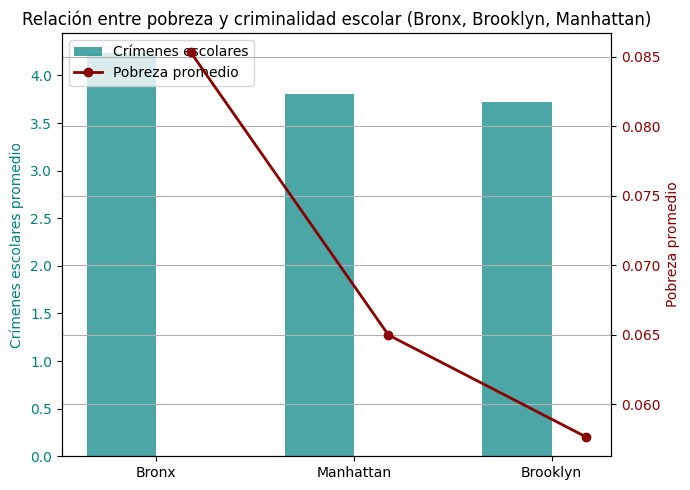

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Usamos pdf_subset que ya definiste
x = np.arange(len(pdf_subset))
width = 0.35

fig, ax1 = plt.subplots(figsize=(7,5))

# Barras: crímenes escolares
ax1.bar(x - width/2, pdf_subset["CrimenesEscolaresPromedio"], width, color="teal", alpha=0.7, label="Crímenes escolares")
ax1.set_ylabel("Crímenes escolares promedio", color="teal")
ax1.tick_params(axis='y', labelcolor="teal")

# Línea: pobreza promedio
ax2 = ax1.twinx()
ax2.plot(x + width/2, pdf_subset["PobrezaPromedio"], color="darkred", marker="o", linewidth=2, label="Pobreza promedio")
ax2.set_ylabel("Pobreza promedio", color="darkred")
ax2.tick_params(axis='y', labelcolor="darkred")

# Configurar eje x
plt.xticks(x, pdf_subset["Distrito"])
plt.title("Relación entre pobreza y criminalidad escolar (Bronx, Brooklyn, Manhattan)")

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.grid(True)
plt.tight_layout()
plt.show()



